In [2]:
import pandas as pd
import numpy as np

# Create dataframe
data = {
    'ID': range(1, 11),
    'Age': [25, 30, 28, np.nan, 35, 40, 32, np.nan, 38, 29],
    'Salary': [50000, 60000, np.nan, 58000, 65000, 70000, 62000, np.nan, 68000, 59000],
    'Experience': [2, 5, 3, np.nan, 7, 10, 6, 4, np.nan, 4],
    'Department': ['Sales', 'Marketing', 'Sales', 'IT', 'Marketing', 'IT', 'Sales', 'Marketing', 'IT', 'Sales'],
    'Gender': ['M', 'F', 'M', 'F', 'F', 'M', 'F', 'M', 'F', 'F']
}

df = pd.DataFrame(data)
print(df)

   ID   Age   Salary  Experience Department Gender
0   1  25.0  50000.0         2.0      Sales      M
1   2  30.0  60000.0         5.0  Marketing      F
2   3  28.0      NaN         3.0      Sales      M
3   4   NaN  58000.0         NaN         IT      F
4   5  35.0  65000.0         7.0  Marketing      F
5   6  40.0  70000.0        10.0         IT      M
6   7  32.0  62000.0         6.0      Sales      F
7   8   NaN      NaN         4.0  Marketing      M
8   9  38.0  68000.0         NaN         IT      F
9  10  29.0  59000.0         4.0      Sales      F


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          10 non-null     int64  
 1   Age         8 non-null      float64
 2   Salary      8 non-null      float64
 3   Experience  8 non-null      float64
 4   Department  10 non-null     object 
 5   Gender      10 non-null     object 
dtypes: float64(3), int64(1), object(2)
memory usage: 612.0+ bytes


In [4]:
df['Salary'].dtypes

dtype('float64')

In [5]:
# 1. separate the numeric and categorical columns 

num_cols = df.select_dtypes(include= ['int64','float64'])
cat_cols = df.select_dtypes(include= ['object'])

num_cols.corr()


    


,ID,Age,Salary,Experience
ID,1.000000,0.498952,0.550000,0.268002
Age,0.498952,1.000000,0.976139,0.992655
Salary,0.550000,0.976139,1.000000,0.973235
Experience,0.268002,0.992655,0.973235,1.000000


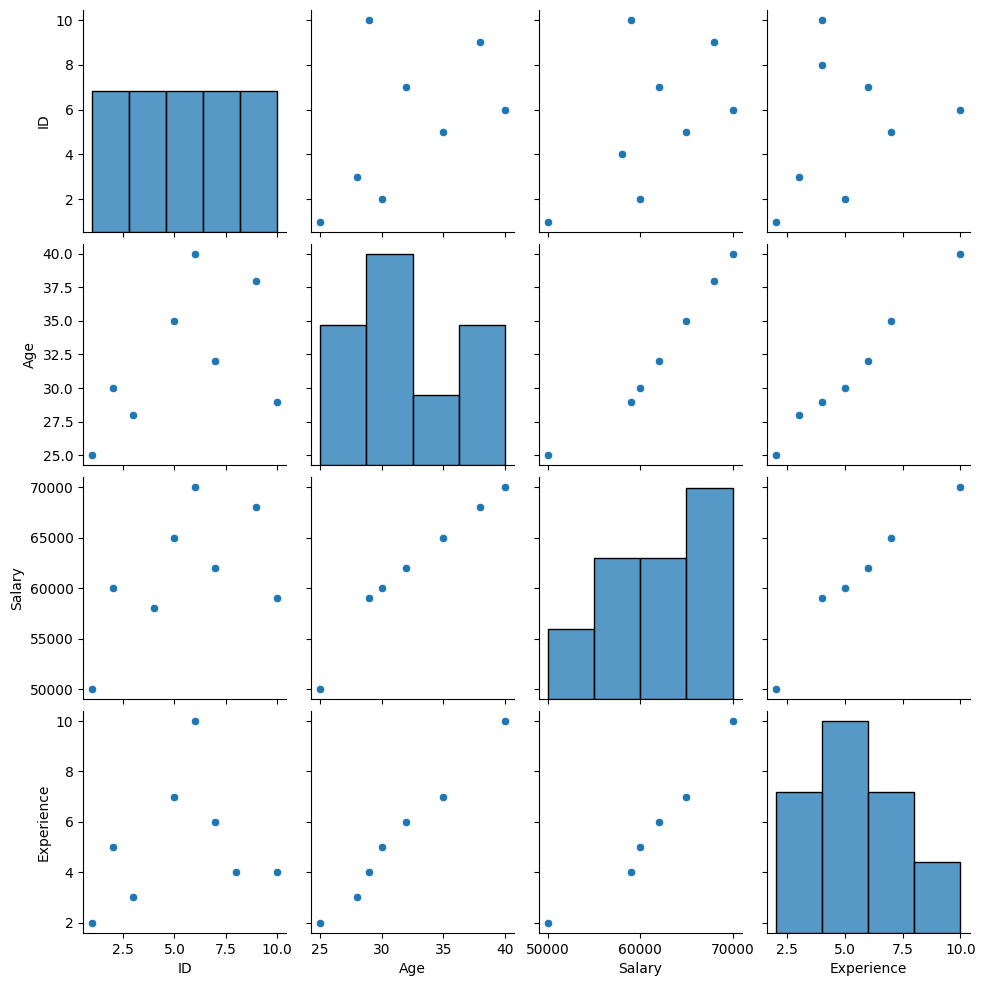

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt 
sns.pairplot(df)
plt.show()

In [9]:
#Scaling our data on the numeric part 

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
nums_cols = scaler.fit_transform(num_cols)

print(nums_cols)
print()
print()
print(num_cols)


[[-1.5666989  -1.47419271 -1.94385479 -1.31944953]
 [-1.21854359 -0.43967151 -0.25354628 -0.05277798]
 [-0.87038828 -0.85347999         nan -0.89722568]
 [-0.52223297         nan -0.59160798         nan]
 [-0.17407766  0.59484969  0.59160798  0.79166972]
 [ 0.17407766  1.62937089  1.43676223  2.05834127]
 [ 0.52223297 -0.02586303  0.08451543  0.36944587]
 [ 0.87038828         nan         nan -0.47500183]
 [ 1.21854359  1.21556241  1.09870053         nan]
 [ 1.5666989  -0.64657575 -0.42257713 -0.47500183]]


   ID   Age   Salary  Experience
0   1  25.0  50000.0         2.0
1   2  30.0  60000.0         5.0
2   3  28.0      NaN         3.0
3   4   NaN  58000.0         NaN
4   5  35.0  65000.0         7.0
5   6  40.0  70000.0        10.0
6   7  32.0  62000.0         6.0
7   8   NaN      NaN         4.0
8   9  38.0  68000.0         NaN
9  10  29.0  59000.0         4.0


In [34]:
# Use model of KNN imputations

from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors= 5)

imputed = imputer.fit_transform(nums_cols)
imputed

array([[-1.5666989 , -1.47419271, -1.94385479, -1.31944953],
       [-1.21854359, -0.43967151, -0.25354628, -0.05277798],
       [-0.87038828, -0.85347999, -0.42257713, -0.89722568],
       [-0.52223297, -0.43967151, -0.59160798, -0.22166752],
       [-0.17407766,  0.59484969,  0.59160798,  0.79166972],
       [ 0.17407766,  1.62937089,  1.43676223,  2.05834127],
       [ 0.52223297, -0.02586303,  0.08451543,  0.36944587],
       [ 0.87038828,  0.05689867,  0.15212777, -0.47500183],
       [ 1.21854359,  1.21556241,  1.09870053,  0.45389064],
       [ 1.5666989 , -0.64657575, -0.42257713, -0.47500183]])

In [35]:
# put back the imputed back to dataframe |remove the scale |
imputed = scaler.inverse_transform(imputed)
df_nums = pd.DataFrame(imputed , columns=num_cols.columns)
df_nums

,ID,Age,Salary,Experience
0,1.0,25.0,50000.0,2.0
1,2.0,30.0,60000.0,5.0
2,3.0,28.0,59000.0,3.0
3,4.0,30.0,58000.0,4.6
4,5.0,35.0,65000.0,7.0
5,6.0,40.0,70000.0,10.0
6,7.0,32.0,62000.0,6.0
7,8.0,32.4,62400.0,4.0
8,9.0,38.0,68000.0,6.2
9,10.0,29.0,59000.0,4.0


In [ ]:
# Working for categorical variable 
# step 1. Encoding using one hot encoding perfect for both nominal and non-nominal 
cat_cols = pd.DataFrame(cat_cols)
df_encode = pd.get_dummies(cat_cols, columns=['Department', 'Gender'])
df_encode = df_encode.astype(int)
df_encode

,Department_IT,Department_Marketing,Department_Sales,Gender_F,Gender_M
0,0,0,1,0,1
1,0,1,0,1,0
2,0,0,1,0,1
3,1,0,0,1,0
4,0,1,0,1,0
5,1,0,0,0,1
6,0,0,1,1,0
7,0,1,0,0,1
8,1,0,0,1,0
9,0,0,1,1,0


In [ ]:
# Imputing using the KNN imputer 
from  sklearn.impute import KNNImputer
impute = KNNImputer(n_neighbors=3)
imputed = impute.fit_transform(df_encode)
imputed 

array([[0., 0., 1., 0., 1.],
       [0., 1., 0., 1., 0.],
       [0., 0., 1., 0., 1.],
       [1., 0., 0., 1., 0.],
       [0., 1., 0., 1., 0.],
       [1., 0., 0., 0., 1.],
       [0., 0., 1., 1., 0.],
       [0., 1., 0., 0., 1.],
       [1., 0., 0., 1., 0.],
       [0., 0., 1., 1., 0.]])

In [ ]:
df_cols = pd.DataFrame(imputed, columns= df_encode.columns)
df_cols = df_cols.round(0).astype(int)
df_cols

,Department_IT,Department_Marketing,Department_Sales,Gender_F,Gender_M
0,0,0,1,0,1
1,0,1,0,1,0
2,0,0,1,0,1
3,1,0,0,1,0
4,0,1,0,1,0
5,1,0,0,0,1
6,0,0,1,1,0
7,0,1,0,0,1
8,1,0,0,1,0
9,0,0,1,1,0


In [65]:
df_cols['Department'] = df_cols[['Department_IT','Department_Marketing','Department_Sales']].idxmax(axis=1)
df_cols['Gender'] = df_cols[['Gender_F', 'Gender_M']].idxmax(axis=1)
df_cols['Department'] = df_cols['Department'].str.replace('Department_','')
df_cols['Gender'] = df_cols['Gender'].str.replace('Gender_','')
df_cols = df_cols[['Department', 'Gender']]

In [66]:
df_cols

,Department,Gender
0,Sales,M
1,Marketing,F
2,Sales,M
3,IT,F
4,Marketing,F
5,IT,M
6,Sales,F
7,Marketing,M
8,IT,F
9,Sales,F


In [67]:
the_imputed = pd.concat([df_nums, df_cols] , axis=1)
the_imputed

,ID,Age,Salary,Experience,Department,Gender
0,1.0,25.0,50000.0,2.0,Sales,M
1,2.0,30.0,60000.0,5.0,Marketing,F
2,3.0,28.0,59000.0,3.0,Sales,M
3,4.0,30.0,58000.0,4.6,IT,F
4,5.0,35.0,65000.0,7.0,Marketing,F
5,6.0,40.0,70000.0,10.0,IT,M
6,7.0,32.0,62000.0,6.0,Sales,F
7,8.0,32.4,62400.0,4.0,Marketing,M
8,9.0,38.0,68000.0,6.2,IT,F
9,10.0,29.0,59000.0,4.0,Sales,F


So this is the whole kNN imputations we should follow to work with 
